In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import datetime as dt
import warnings 
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("D:/ML projects/Project_1(Customer Segmentation)/Data/processed/output.csv")

df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
...,...,...,...,...,...,...,...,...
401599,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France
401600,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France
401601,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France
401602,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France


In [3]:
# Create Total Price
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [4]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
401599,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,10.20
401600,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60
401601,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60
401602,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60


In [5]:
# Reference Date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
reference_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

In [6]:
# Create RFM Table
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                    # Frequency
    'TotalPrice': 'sum'                                        # Monetary
})

In [7]:
rfm

,InvoiceDate,InvoiceNo,TotalPrice
CustomerID,,,
12346,326,2,0.00
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40
...,...,...,...
18280,278,1,180.60
18281,181,1,80.82
18282,8,3,176.60


In [8]:
# Renaming Columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.reset_index(inplace=True)

In [9]:
rfm

,CustomerID,Recency,Frequency,Monetary
0,12346,326,2,0.00
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40
...,...,...,...,...
4367,18280,278,1,180.60
4368,18281,181,1,80.82
4369,18282,8,3,176.60
4370,18283,4,16,2045.53


In [10]:
rfm.head()
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4372.000000,4372.000000,4372.000000,4372.000000
mean,15299.677722,92.047118,5.075480,1893.531433
std,1722.390705,100.765435,9.338754,8218.696204
min,12346.000000,1.000000,1.000000,-4287.630000
25%,13812.750000,17.000000,1.000000,291.795000
50%,15300.500000,50.000000,3.000000,644.070000
75%,16778.250000,143.000000,5.000000,1608.335000
max,18287.000000,374.000000,248.000000,279489.020000


In [11]:
# Remove Extreme Outliers
rfm = rfm[rfm['Monetary'] > 0]

In [12]:
rfm

,CustomerID,Recency,Frequency,Monetary
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40
5,12352,36,11,1545.41
...,...,...,...,...
4367,18280,278,1,180.60
4368,18281,181,1,80.82
4369,18282,8,3,176.60
4370,18283,4,16,2045.53


In [13]:
# Use IQR Filtering to remove outliers

Q1 = rfm.quantile(0.25)
Q3 = rfm.quantile(0.75)
IQR = Q3 - Q1

rfm = rfm[~((rfm < (Q1 - 1.5 * IQR)) | (rfm > (Q3 + 1.5 * IQR))).any(axis=1)]


In [14]:
rfm

,CustomerID,Recency,Frequency,Monetary
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40
5,12352,36,11,1545.41
6,12353,204,1,89.00
...,...,...,...,...
4366,18278,74,1,173.90
4367,18280,278,1,180.60
4368,18281,181,1,80.82
4369,18282,8,3,176.60


# Feature Scaling

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

In [16]:
rfm_scaled

array([[-0.13976826,  0.26120716,  1.18877114],
       [-0.78449134, -0.87041629,  1.13831685],
       [ 2.56576611, -0.87041629, -0.67080466],
       ...,
       [ 1.08060043, -0.87041629, -0.99315791],
       [-0.91113338, -0.11600066, -0.87140149],
       [-0.50818145, -0.11600066,  1.23967036]], shape=(3668, 3))

In [17]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

In [18]:
rfm_pca

array([[ 0.972411  ,  0.37515951],
       [ 0.51292242, -0.53500688],
       [-2.13404674,  1.79886475],
       ...,
       [-1.66339821,  0.36121606],
       [-0.20609059, -1.1560784 ],
       [ 0.93104483, -0.04060478]], shape=(3668, 2))

In [19]:
# Optimal K (Elbow Method)
from sklearn.cluster import KMeans

wcss = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

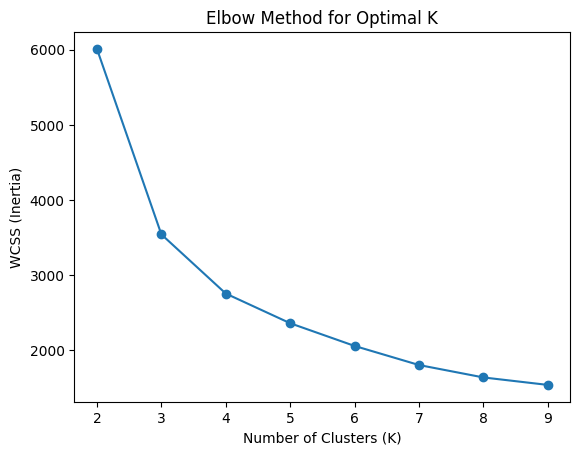

In [21]:
import matplotlib.pyplot as plt

k_values = range(2, 10)

plt.figure()
plt.plot(k_values, wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method for Optimal K')
plt.show()

In [22]:
# Silhouette Score # Higher silhouette score → better clustering
# Used for cross-checking with elbow method 
from sklearn.metrics import silhouette_score

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)
    print(k, silhouette_score(rfm_scaled, labels))

2 0.4488118150938506
3 0.4561169491918231
4 0.4112168694866452
5 0.39823542017538044
6 0.3659041789275377
7 0.3456507977571019
8 0.34021515417876846
9 0.31049573685681453


In [23]:
# Final Clustering

kmeans = KMeans(n_clusters=3, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [24]:
rfm.groupby('Cluster').mean()

,CustomerID,Recency,Frequency,Monetary
Cluster,,,,
0,15344.593168,46.818323,2.374741,574.024437
1,15361.734899,221.869128,1.765101,403.140380
2,15237.245843,36.610451,7.085511,2010.361118


In [25]:
# Final Segment Mapping
cluster_map = {
    0: 'Regular Customers',
    1: 'Churned Customers',
    2: 'High Value Customers'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_map)

In [26]:
rfm

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
2,12348,75,4,1797.24,2,High Value Customers
3,12349,19,1,1757.55,0,Regular Customers
4,12350,310,1,334.40,1,Churned Customers
5,12352,36,11,1545.41,2,High Value Customers
6,12353,204,1,89.00,1,Churned Customers
...,...,...,...,...,...,...
4366,18278,74,1,173.90,0,Regular Customers
4367,18280,278,1,180.60,1,Churned Customers
4368,18281,181,1,80.82,1,Churned Customers
4369,18282,8,3,176.60,0,Regular Customers


In [27]:
rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().sort_values(by='Monetary', ascending=False)

,Recency,Frequency,Monetary
Cluster,,,
2,36.610451,7.085511,2010.361118
0,46.818323,2.374741,574.024437
1,221.869128,1.765101,403.140380


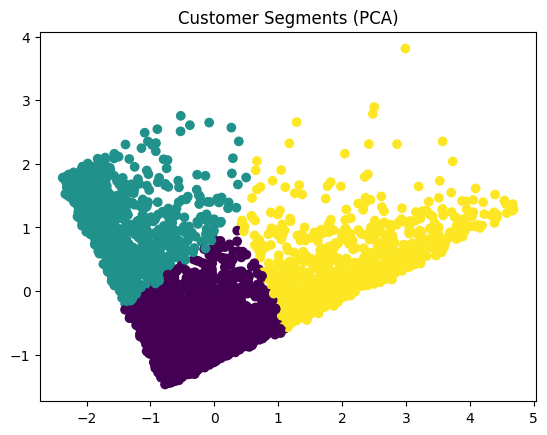

In [28]:


plt.scatter(rfm_pca[:,0], rfm_pca[:,1], c=rfm['Cluster'])
plt.title('Customer Segments (PCA)')
plt.show()

# Modeling

In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

In [29]:
# Feature separating
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['Cluster']

In [30]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y
)

In [32]:
# Random Forest Model

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [34]:
# classification_report
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       387
           1       0.98      0.99      0.99       179
           2       0.99      0.99      0.99       168

    accuracy                           0.99       734
   macro avg       0.99      0.99      0.99       734
weighted avg       0.99      0.99      0.99       734



In [36]:
# XGBoost

xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb.fit(X_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [37]:
y_pred_xgb = xgb.predict(X_test)
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       387
           1       0.99      0.99      0.99       179
           2       0.99      0.99      0.99       168

    accuracy                           0.99       734
   macro avg       0.99      0.99      0.99       734
weighted avg       0.99      0.99      0.99       734



In [40]:
# Hyperparameter Tuning

# Random Forest
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(rf, rf_params, cv=5, scoring='f1_weighted')
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

# XGBoost

xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1]
}

grid_xgb = GridSearchCV(xgb, xgb_params, cv=5, scoring='f1_weighted')
grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_

<Axes: >

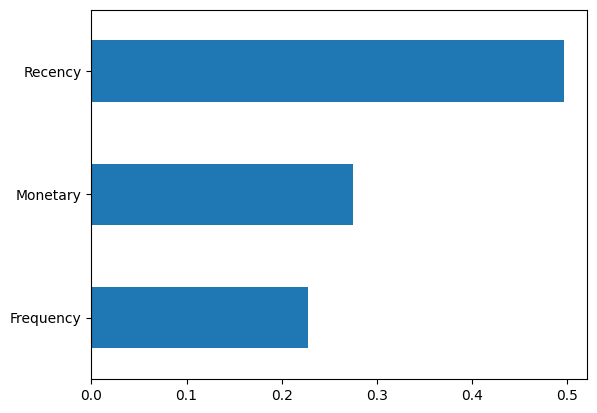

In [41]:
# Feature Importance
importance = pd.Series(best_rf.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')

In [42]:
# Save model
import joblib

joblib.dump(best_xgb, 'D:\ML projects\Project_1(Customer Segmentation)\models/customer_segment_model.pkl')

['D:\\ML projects\\Project_1(Customer Segmentation)\\models/customer_segment_model.pkl']